In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv('datasets/predicciones_modelo_split_antiguo.csv')

def ml_to_decimal(ml):
    """Moneyline americano -> cuota decimal (incluye devolucion del stake)."""
    ml = pd.to_numeric(ml, errors='coerce')
    return np.where(ml < 0, 1 + 100/(-ml), 1 + ml/100)

def ml_to_prob(ml):
    """Moneyline americano -> probabilidad implicita (con vig)."""
    ml = pd.to_numeric(ml, errors='coerce')
    return np.where(ml < 0, -ml/(-ml + 100), 100/(ml + 100))

# Cuotas y probabilidades
df['dec_home']   = ml_to_decimal(df['moneyline_home'])
df['dec_away']   = ml_to_decimal(df['moneyline_away'])
imp_h, imp_a     = ml_to_prob(df['moneyline_home']), ml_to_prob(df['moneyline_away'])
df['prob_vegas_home'] = imp_h / (imp_h + imp_a)        # sin vig
df['prob_model_away'] = 1 - df['prob_home_win']

# EV apostando 1 unidad
df['ev_home'] = df['prob_home_win']    * df['dec_home'] - 1
df['ev_away'] = df['prob_model_away']  * df['dec_away'] - 1

# Resultado y profit por bet
df['away_won']  = 1 - df['home_team_won']
df['pf_home']   = np.where(df['home_team_won']==1, df['dec_home']-1, -1)
df['pf_away']   = np.where(df['away_won']==1,      df['dec_away']-1, -1)

def simular(nombre, mh, ma):
    apuestas = mh.sum() + ma.sum()
    if apuestas == 0:
        print(f"{nombre:48} sin apuestas"); return
    profit = df.loc[mh, 'pf_home'].sum() + df.loc[ma, 'pf_away'].sum()
    aciertos = (df.loc[mh, 'home_team_won']==1).sum() + (df.loc[ma, 'away_won']==1).sum()
    roi = profit / apuestas * 100
    print(f"{nombre:48} n={apuestas:4}  aciertos={aciertos:4} ({aciertos/apuestas:.1%})  "
          f"profit={profit:+7.1f}u   ROI={roi:+6.2f}%")

print(f"Baseline (apostar SIEMPRE local): "
      f"profit={(df['pf_home']).sum():+.1f}u   ROI={df['pf_home'].mean()*100:+.2f}%\n")

# A) Cualquier EV positivo
simular("A) Cualquier EV > 0",
        df['ev_home'] > 0, df['ev_away'] > 0)

# B) Edge mas exigente (EV > 5%)
simular("B) EV > 5%",
        df['ev_home'] > 0.05, df['ev_away'] > 0.05)

# C) EV+ con confianza alta del modelo (>0.6)
simular("C) EV+ y prob modelo > 0.6",
        (df['ev_home'] > 0) & (df['prob_home_win'] > 0.6),
        (df['ev_away'] > 0) & (df['prob_model_away'] > 0.6))

# D) Edge en probabilidad >10% (tu prob - vegas)
edge_h = df['prob_home_win']    - df['prob_vegas_home']
edge_a = df['prob_model_away']  - (1 - df['prob_vegas_home'])
simular("D) Edge de probabilidad > 10%",
        edge_h > 0.10, edge_a > 0.10)

# E) EV+ evitando favoritos extremos (menos -300)
simular("E) EV+ y moneyline > -300",
        (df['ev_home'] > 0) & (df['moneyline_home'] > -300),
        (df['ev_away'] > 0) & (df['moneyline_away'] > -300))

# F) Kelly fraccional (1/4): tamano de stake proporcional al edge
def kelly_simulate(frac=0.25):
    total, n, wins = 0.0, 0, 0
    for side, dec_col, prob_col, won_col in [
        ('home', 'dec_home', 'prob_home_win',   'home_team_won'),
        ('away', 'dec_away', 'prob_model_away', 'away_won')]:
        sub = df[df[f'ev_{side}'] > 0]
        b = sub[dec_col] - 1
        p = sub[prob_col]
        f = ((b*p - (1-p)) / b * frac).clip(lower=0)
        outcome = sub[won_col]
        profit = np.where(outcome==1, f*b, -f)
        total += profit.sum()
        n     += (f > 0).sum()
        wins  += outcome[f > 0].sum()
    print(f"F) Kelly fraccional 1/4                          n={n:4}  aciertos={wins:4} ({wins/n:.1%})  "
          f"profit={total:+7.2f}u   (stakes variables)")

kelly_simulate(frac=0.25)

Baseline (apostar SIEMPRE local): profit=-157.9u   ROI=-3.28%

A) Cualquier EV > 0                              n=4094  aciertos=1626 (39.7%)  profit= -166.3u   ROI= -4.06%
B) EV > 5%                                       n=3314  aciertos=1208 (36.5%)  profit= -115.6u   ROI= -3.49%
C) EV+ y prob modelo > 0.6                       n=1306  aciertos= 800 (61.3%)  profit=  -67.2u   ROI= -5.15%
D) Edge de probabilidad > 10%                    n=1509  aciertos= 590 (39.1%)  profit=  +35.4u   ROI= +2.34%
E) EV+ y moneyline > -300                        n=3812  aciertos=1412 (37.0%)  profit= -149.0u   ROI= -3.91%
F) Kelly fraccional 1/4                          n=4094  aciertos=1626 (39.7%)  profit=  -1.95u   (stakes variables)


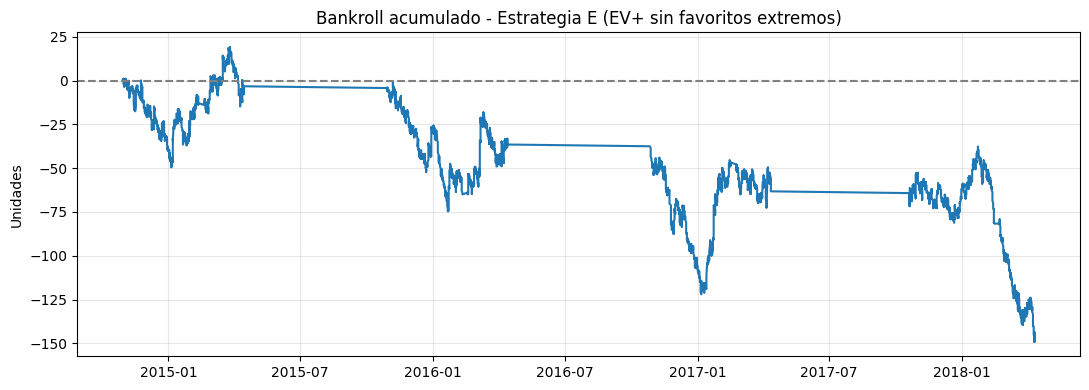

In [26]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values('GAME_DATE').copy()
mh = (df_sorted['ev_home'] > 0) & (df_sorted['moneyline_home'] > -300)
ma = (df_sorted['ev_away'] > 0) & (df_sorted['moneyline_away'] > -300)
df_sorted['pf_E'] = 0.0
df_sorted.loc[mh, 'pf_E'] += df_sorted.loc[mh, 'pf_home']
df_sorted.loc[ma, 'pf_E'] += df_sorted.loc[ma, 'pf_away']
df_sorted['bankroll'] = df_sorted['pf_E'].cumsum()

plt.figure(figsize=(11, 4))
plt.plot(pd.to_datetime(df_sorted['GAME_DATE']), df_sorted['bankroll'])
plt.axhline(0, color='gray', linestyle='--')
plt.title('Bankroll acumulado - Estrategia E (EV+ sin favoritos extremos)')
plt.ylabel('Unidades'); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd

# Apuestas candidatas (Estrategia E)
mh = (df['ev_home'] > 0) & (df['moneyline_home'] > -300)
ma = (df['ev_away'] > 0) & (df['moneyline_away'] > -300)

h = df[mh].assign(p=df['prob_home_win'], dec=df['dec_home'], won=df['home_team_won'])
a = df[ma].assign(p=df['prob_model_away'], dec=df['dec_away'], won=df['away_won'])
bets = pd.concat([h, a], ignore_index=True)
bets['ev']    = bets['p'] * bets['dec'] - 1
bets['edge']  = bets['p'] - 1/bets['dec']
bets['pf_u']  = np.where(bets['won']==1, bets['dec']-1, -1)   # profit por 1u

def eval_stake(nombre, stake):
    total = stake.sum()
    profit = (stake * bets['pf_u']).sum()
    print(f"{nombre:42} stake_total={total:7.0f}u  profit={profit:+7.1f}u  ROI={profit/total*100:+5.2f}%")

# 1) Flat 1u (referencia, tu E actual)
eval_stake("Flat 1u (referencia)", pd.Series(1.0, index=bets.index))

# 2) Proporcional al EDGE en probabilidad (a mas edge, mas pongo)
eval_stake("Proporcional al edge (0.5-3u)",
           (bets['edge'] * 10).clip(0.5, 3.0))

# 3) Proporcional al EV
eval_stake("Proporcional al EV (0.5-3u)",
           (bets['ev'] * 15).clip(0.5, 3.0))

# 4) Tier por confianza del modelo
tier_stake = bets['p'].apply(lambda p: 2.0 if p > 0.65 else 1.5 if p > 0.55 else 1.0)
eval_stake("Tier por confianza (1/1.5/2u)", tier_stake)

# 5) Kelly completo (matematicamente optimo, MUY volatil)
b = bets['dec'] - 1
kelly = ((b*bets['p'] - (1-bets['p'])) / b).clip(lower=0)
eval_stake("Kelly completo (sin freno)", kelly)

# 6) Kelly 1/2 (mas suave)
eval_stake("Kelly 1/2", kelly * 0.5)

# 7) Kelly 1/4 (lo prudente)
eval_stake("Kelly 1/4", kelly * 0.25)

# 8) Mas peso en underdogs (cuotas >2)
under_stake = pd.Series(np.where(bets['dec'] > 2.0, 2.0, 1.0), index=bets.index)
eval_stake("2u en underdogs, 1u en favoritos", under_stake)

# 9) Anti-favoritos: solo apuesto si cuota >1.7 (evitar favoritos pequenos)
mask = bets['dec'] > 1.7
eval_stake("Solo cuotas > 1.7 (flat 1u)",
           pd.Series(np.where(mask, 1.0, 0.0), index=bets.index))

Flat 1u (referencia)                       stake_total=   3812u  profit= -149.0u  ROI=-3.91%
Proporcional al edge (0.5-3u)              stake_total=   3504u  profit=  -22.6u  ROI=-0.65%
Proporcional al EV (0.5-3u)                stake_total=   8208u  profit= -166.9u  ROI=-2.03%
Tier por confianza (1/1.5/2u)              stake_total=   4857u  profit= -200.0u  ROI=-4.12%
Kelly completo (sin freno)                 stake_total=    548u  profit=   -5.3u  ROI=-0.97%
Kelly 1/2                                  stake_total=    274u  profit=   -2.7u  ROI=-0.97%
Kelly 1/4                                  stake_total=    137u  profit=   -1.3u  ROI=-0.97%
2u en underdogs, 1u en favoritos           stake_total=   6523u  profit= -235.0u  ROI=-3.60%
Solo cuotas > 1.7 (flat 1u)                stake_total=   3138u  profit= -102.0u  ROI=-3.25%


In [28]:
mask = bets['dec'] > 1.7
stake = pd.Series(np.where(bets['dec'] > 2.0, 2.0, 1.0), index=bets.index) * mask
eval_stake("Underdog 2u + filtro cuota >1.7", stake)

Underdog 2u + filtro cuota >1.7            stake_total=   5849u  profit= -188.1u  ROI=-3.22%


Bankroll inicial: $1000

Estrategia                          Final   Bets   Aciertos    Max DD
---------------------------------------------------------------------------
Kelly 100% (peligroso)         $    0.00 (-100.0%)    3138      31.8%    100.0%
Kelly 50%                      $    0.00 (-100.0%)    3138      31.8%    100.0%
Kelly 25% (recomendado)        $   33.21 (-96.7%)    3138      31.8%     98.0%
Kelly 10% (muy seguro)         $  588.26 (-41.2%)    3138      31.8%     73.8%
Kelly 5% (muy conservador)     $  964.24 ( -3.6%)    3138      31.8%     41.8%


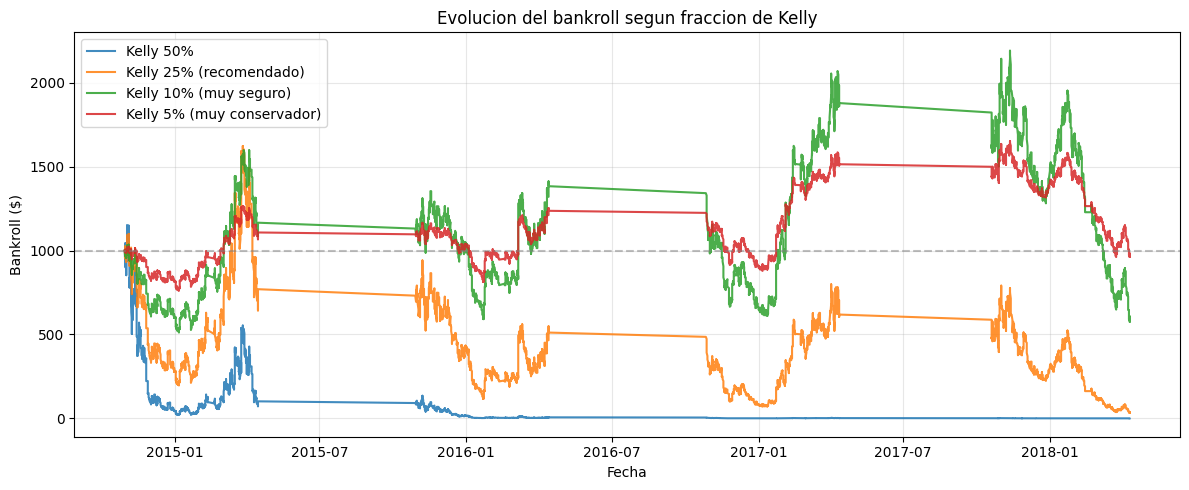

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('datasets/predicciones_modelo_split_antiguo.csv')

def ml_to_decimal(ml):
    ml = pd.to_numeric(ml, errors='coerce')
    return np.where(ml < 0, 1 + 100/(-ml), 1 + ml/100)

df['dec_home']        = ml_to_decimal(df['moneyline_home'])
df['dec_away']        = ml_to_decimal(df['moneyline_away'])
df['prob_model_away'] = 1 - df['prob_home_win']
df['ev_home']         = df['prob_home_win']   * df['dec_home'] - 1
df['ev_away']         = df['prob_model_away'] * df['dec_away'] - 1
df['away_won']        = 1 - df['home_team_won']
df = df.sort_values('GAME_DATE').reset_index(drop=True)   # cronologico OBLIGATORIO

def kelly_f(p, dec):
    """Fraccion optima de Kelly: f* = (b*p - q) / b, b = cuota-1"""
    b = dec - 1
    return max(0.0, (b*p - (1-p)) / b)

def simular_kelly(df, bankroll_ini=1000, kelly_frac=0.25,
                  filtro_cuota=1.7, cap_stake=0.05):
    """
    Simula apuestas en orden cronologico actualizando el bankroll despues de cada partido.

    kelly_frac : fraccion de Kelly aplicada (0.25 = 1/4 Kelly, conservador)
    filtro_cuota : solo apuesta si la cuota > este valor (evita favoritos pesados)
    cap_stake : tope maximo del bet como % del bankroll actual (red de seguridad)
    """
    bankroll = bankroll_ini
    hist, n_bets, n_wins = [], 0, 0

    for _, r in df.iterrows():
        # Bet al local
        if r['ev_home'] > 0 and r['dec_home'] > filtro_cuota:
            f = min(kelly_f(r['prob_home_win'], r['dec_home']) * kelly_frac, cap_stake)
            stake = bankroll * f
            if stake > 0:
                profit = stake * (r['dec_home']-1) if r['home_team_won']==1 else -stake
                bankroll += profit
                n_bets += 1
                n_wins += r['home_team_won']

        # Bet al visitante
        if r['ev_away'] > 0 and r['dec_away'] > filtro_cuota:
            f = min(kelly_f(r['prob_model_away'], r['dec_away']) * kelly_frac, cap_stake)
            stake = bankroll * f
            if stake > 0:
                profit = stake * (r['dec_away']-1) if r['away_won']==1 else -stake
                bankroll += profit
                n_bets += 1
                n_wins += r['away_won']

        hist.append((r['GAME_DATE'], bankroll))

    return pd.DataFrame(hist, columns=['date','bankroll']), n_bets, n_wins

# Comparar varios escenarios
print(f"Bankroll inicial: $1000\n")
print(f"{'Estrategia':30} {'Final':>10} {'Bets':>6} {'Aciertos':>10} {'Max DD':>9}")
print("-" * 75)
escenarios = [
    ("Kelly 100% (peligroso)", 1.00, 1.00),
    ("Kelly 50%",              0.50, 0.10),
    ("Kelly 25% (recomendado)",0.25, 0.05),
    ("Kelly 10% (muy seguro)", 0.10, 0.03),
    ("Kelly 5% (muy conservador)", 0.05, 0.01)
]

resultados = {}
for nombre, kf, cap in escenarios:
    hist, n, w = simular_kelly(df, bankroll_ini=1000, kelly_frac=kf, cap_stake=cap)
    final = hist['bankroll'].iloc[-1]
    max_dd = ((hist['bankroll'].cummax() - hist['bankroll']) /
              hist['bankroll'].cummax()).max()
    pct = (final/1000 - 1) * 100
    print(f"{nombre:30} ${final:8.2f} ({pct:+5.1f}%)  {n:>6}  {w/n:>9.1%}  {max_dd:>8.1%}")
    resultados[nombre] = hist

# Curva del bankroll
fig, ax = plt.subplots(figsize=(12, 5))
for nombre, hist in resultados.items():
    if "100%" in nombre: continue   # esta suele reventarse, le quita escala al grafico
    ax.plot(pd.to_datetime(hist['date']), hist['bankroll'], label=nombre, alpha=0.85)
ax.axhline(1000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Evolucion del bankroll segun fraccion de Kelly')
ax.set_ylabel('Bankroll ($)'); ax.set_xlabel('Fecha')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# KELLY SOLO FUNCIONA CON PROBABILIDADES BIEN CALIBRADAS. SI EL MODELO NO CALIBRA, PUEDE SER PEOR QUE UN FLAT BET (1u fijo). SI EL MODELO ES MUY BUENO Y CALIBRA, KELLY PUEDE DAR UNA VENTAJA IMPORTANTE A LARGO PLAZO. EN LA PRACTICA, USAR 1/4 O 1/2 KELLY SUELE SER UNA BUENA OPCION PARA CONTROLAR LA VOLATILIDAD.

Bankroll inicial: $1000

Metodo                                  Final   Bets   Aciertos    Max DD
---------------------------------------------------------------------------
Flat 1% (referencia)           $  229.89 ( -77.0%)   3138      31.8%     77.2%
Confidence-bracket             $  674.02 ( -32.6%)   1649      41.9%     66.7%
Square-root EV                 $    2.92 ( -99.7%)   3138      31.8%     99.7%
Anti-Kelly                     $    1.60 ( -99.8%)   3138      31.8%     99.8%
EV-band 2-10%                  $  222.75 ( -77.7%)    609      35.6%     82.3%
EV-band 1-15%                  $   60.56 ( -93.9%)   1027      34.9%     94.1%
EV-band 2-20%                  $   62.88 ( -93.7%)   1265      35.2%     93.7%
EV-band 3-15%                  $   85.13 ( -91.5%)    869      34.8%     91.7%
EV-band 5-20%                  $  104.71 ( -89.5%)   1039      34.9%     89.8%


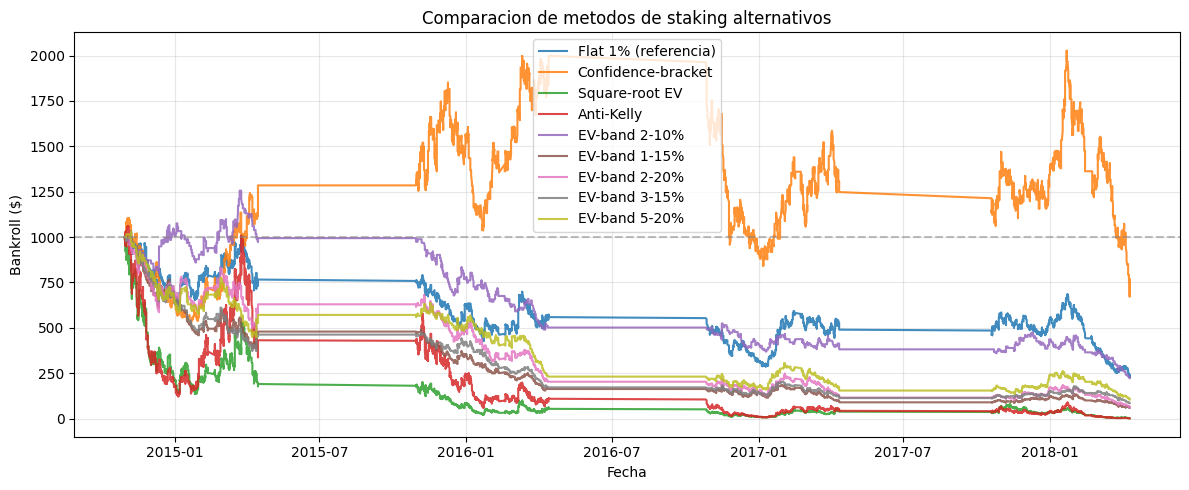

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Asume que df ya tiene cuotas, EV, etc. de la celda anterior

def simular(df, stake_fn, bankroll_ini=1000, cap=0.05, filtro_cuota=1.7):
    """Simulador generico. stake_fn devuelve la fraccion del bankroll a apostar."""
    bankroll = bankroll_ini
    hist, n, w = [], 0, 0
    for _, r in df.iterrows():
        for side in ['home', 'away']:
            p   = r['prob_home_win']   if side=='home' else r['prob_model_away']
            dec = r['dec_home']        if side=='home' else r['dec_away']
            won = r['home_team_won']   if side=='home' else r['away_won']
            ev  = p * dec - 1
            if ev > 0 and dec > filtro_cuota:
                f = min(max(0, stake_fn(p, ev, dec)), cap)
                stake = bankroll * f
                if stake > 0:
                    profit = stake*(dec-1) if won==1 else -stake
                    bankroll += profit
                    n += 1
                    w  += won
        hist.append((r['GAME_DATE'], bankroll))
    return pd.DataFrame(hist, columns=['date','bankroll']), n, w

# ===== Metodos a comparar =====
def flat_baseline(p, ev, dec):
    """Referencia: 1% del bankroll en cada bet con EV+."""
    return 0.01

def confidence_bracket(p, ev, dec):
    """Apuesta MAS en el centro (p~0.55), MENOS en extremos. Curva en U invertida."""
    centro, ancho = 0.55, 0.15
    peso = max(0, 1 - ((p - centro) / ancho)**2)
    return 0.03 * peso

def sqrt_ev(p, ev, dec):
    """Stake proporcional a sqrt(EV): Kelly suavizado, dampens los grandes."""
    return 0.05 * np.sqrt(max(0, ev))

def anti_kelly(p, ev, dec):
    """Apuesta MENOS cuanto mas convencido el modelo. Contra-Kelly puro."""
    sorpresa = 1 - max(p, 1-p)        # 0 en certeza total, 0.5 en coin flip
    return 0.05 * (sorpresa / 0.5)

def ev_band(p, ev, dec, min_ev=0.02, max_ev=0.10):
    """Solo apuesta si EV en rango medio [2%, 10%]: filtra ruido y overconfidence."""
    return 0.02 if min_ev <= ev <= max_ev else 0

# ===== Ejecutar y comparar =====
print(f"Bankroll inicial: $1000\n")
print(f"{'Metodo':30} {'Final':>14} {'Bets':>6} {'Aciertos':>10} {'Max DD':>9}")
print("-" * 75)

resultados = {}
metodos = [
    ("Flat 1% (referencia)",       flat_baseline),
    ("Confidence-bracket",         confidence_bracket),
    ("Square-root EV",             sqrt_ev),
    ("Anti-Kelly",                 anti_kelly),
    ("EV-band 2-10%",              lambda p, ev, dec: ev_band(p, ev, dec, 0.02, 0.10)),
    ("EV-band 1-15%",              lambda p, ev, dec: ev_band(p, ev, dec, 0.01, 0.15)),
    ("EV-band 2-20%",              lambda p, ev, dec: ev_band(p, ev, dec, 0.02, 0.20)),
    ("EV-band 3-15%",              lambda p, ev, dec: ev_band(p, ev, dec, 0.03, 0.15)),
    ("EV-band 5-20%",              lambda p, ev, dec: ev_band(p, ev, dec, 0.05, 0.20)),
]
for nombre, fn in metodos:
    hist, n, w = simular(df, fn, bankroll_ini=1000)
    final = hist['bankroll'].iloc[-1]
    pct   = (final/1000 - 1) * 100
    max_dd = ((hist['bankroll'].cummax() - hist['bankroll'])
              / hist['bankroll'].cummax()).max()
    wr = w/n if n else 0
    print(f"{nombre:30} ${final:8.2f} ({pct:+6.1f}%) {n:>6}  {wr:>9.1%}  {max_dd:>8.1%}")
    resultados[nombre] = hist

# Curva del bankroll
fig, ax = plt.subplots(figsize=(12, 5))
for nombre, hist in resultados.items():
    ax.plot(pd.to_datetime(hist['date']), hist['bankroll'], label=nombre, alpha=0.85)
ax.axhline(1000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Comparacion de metodos de staking alternativos')
ax.set_ylabel('Bankroll ($)'); ax.set_xlabel('Fecha')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()